In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor

In [3]:
df = pd.read_csv("../data/processed/HHS_Feature_Engineered.csv")

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.set_index("Date", inplace=True)

In [5]:
feature_cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children discharged from HHS Care",
    "Month",
    "Day",
    "Year",
    "Quarter",
    "Day_of_Week",
    "Is_Weekend",
    "HHS_Lag_1",
    "HHS_Lag_7",
    "HHS_Lag_14",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_STD_7",
    "Net_Pressure"
]

In [9]:
import joblib

gb_model = joblib.load("../models/gradient_boosting_model.pkl")

In [11]:
X = df[feature_cols]

y = df["Children in HHS Care"]
gb_model.fit(X, y)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [12]:
last_row = df.iloc[-1].copy()

last_row

Children apprehended and placed in CBP custody*              6
Children in CBP custody                                     18
Children transferred out of CBP custody                     11
Children in HHS Care                                      2484
Children discharged from HHS Care                           14
HHS_Lag_1                                               2472.0
HHS_Lag_7                                               2439.0
HHS_Lag_14                                              2410.0
Rolling_Mean_7                                     2467.714286
Rolling_Mean_14                                    2447.785714
Rolling_STD_7                                        15.499616
Net_Pressure                                                -3
Year                                                      2025
Month                                                       12
Day                                                         21
Day_of_Week                                            

In [13]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_dates

DatetimeIndex(['2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31', '2026-01-01', '2026-01-02',
               '2026-01-03', '2026-01-04', '2026-01-05', '2026-01-06',
               '2026-01-07', '2026-01-08', '2026-01-09', '2026-01-10',
               '2026-01-11', '2026-01-12', '2026-01-13', '2026-01-14',
               '2026-01-15', '2026-01-16', '2026-01-17', '2026-01-18',
               '2026-01-19', '2026-01-20'],
              dtype='datetime64[ns]', freq='D')

In [14]:
print(feature_cols)
print(len(feature_cols))

['Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children discharged from HHS Care', 'Month', 'Day', 'Year', 'Quarter', 'Day_of_Week', 'Is_Weekend', 'HHS_Lag_1', 'HHS_Lag_7', 'HHS_Lag_14', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_STD_7', 'Net_Pressure']
17


In [19]:
# Copy historical target values
history = list(df["Children in HHS Care"].values)

# Store future predictions
future_predictions = []

print(len(history))
print(history[-5:])

for future_date in future_dates:

    future_row = last_row.copy()
    future_row["Month"] = future_date.month
    future_row["Day"] = future_date.day
    future_row["Year"] = future_date.year
    future_row["Quarter"] = future_date.quarter
    future_row["Day_of_Week"] = future_date.dayofweek
    future_row["Is_Weekend"] = int(future_date.dayofweek >= 5)
    future_row["HHS_Lag_1"] = history[-1]
    future_row["HHS_Lag_7"] = history[-7]
    future_row["HHS_Lag_14"] = history[-14]
    future_row["Rolling_Mean_7"] = np.mean(history[-7:])
    future_row["Rolling_Mean_14"] = np.mean(history[-14:])
    future_row["Rolling_STD_7"] = np.std(history[-7:])
    print(future_date)
    print(future_row[feature_cols])
    break


706
[np.int64(2470), np.int64(2468), np.int64(2481), np.int64(2472), np.int64(2484)]
2025-12-22 00:00:00
Children apprehended and placed in CBP custody*              6
Children in CBP custody                                     18
Children transferred out of CBP custody                     11
Children discharged from HHS Care                           14
Month                                                       12
Day                                                         22
Year                                                      2025
Quarter                                                      4
Day_of_Week                                                  0
Is_Weekend                                                   0
HHS_Lag_1                                                 2484
HHS_Lag_7                                                 2437
HHS_Lag_14                                                2407
Rolling_Mean_7                                     2467.714286
Rolling_Mean_

In [20]:
for future_date in future_dates:

    future_row = last_row.copy()

    # Calendar Features
    future_row["Month"] = future_date.month
    future_row["Day"] = future_date.day
    future_row["Year"] = future_date.year
    future_row["Quarter"] = future_date.quarter
    future_row["Day_of_Week"] = future_date.dayofweek
    future_row["Is_Weekend"] = int(future_date.dayofweek >= 5)

    # Lag Features
    future_row["HHS_Lag_1"] = history[-1]
    future_row["HHS_Lag_7"] = history[-7]
    future_row["HHS_Lag_14"] = history[-14]

    # Rolling Features
    future_row["Rolling_Mean_7"] = np.mean(history[-7:])
    future_row["Rolling_Mean_14"] = np.mean(history[-14:])
    future_row["Rolling_STD_7"] = np.std(history[-7:])

    # Predict
    X_future = pd.DataFrame([future_row])[feature_cols]
    prediction = gb_model.predict(X_future)[0]

    # Save Prediction
    future_predictions.append(prediction)
    history.append(prediction)

    # Update last row
    last_row["Children in HHS Care"] = prediction

In [21]:
print(len(future_predictions))
print(future_predictions[:5])
print(future_predictions[-5:])

30
[np.float64(2481.086022606713), np.float64(2484.4449665465563), np.float64(2484.3718701832818), np.float64(2485.298034065064), np.float64(2485.298034065064)]
[np.float64(2605.2778050462857), np.float64(2601.8743372249546), np.float64(2598.470634083724), np.float64(2602.054892128962), np.float64(2606.696391692765)]


In [22]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_predictions
})

forecast_df
forecast_df.describe()

,Date,Forecast
count,30,30.000000
mean,2026-01-05 12:00:00,2562.833225
min,2025-12-22 00:00:00,2479.803467
25%,2025-12-29 06:00:00,2485.520308
50%,2026-01-05 12:00:00,2601.874337
75%,2026-01-12 18:00:00,2605.277805
max,2026-01-20 00:00:00,2606.696392
std,NaN,56.784150


In [23]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_HHS_Care": future_predictions
})

forecast_df.head()

,Date,Predicted_HHS_Care
0,2025-12-22,2481.086023
1,2025-12-23,2484.444967
2,2025-12-24,2484.371870
3,2025-12-25,2485.298034
4,2025-12-26,2485.298034


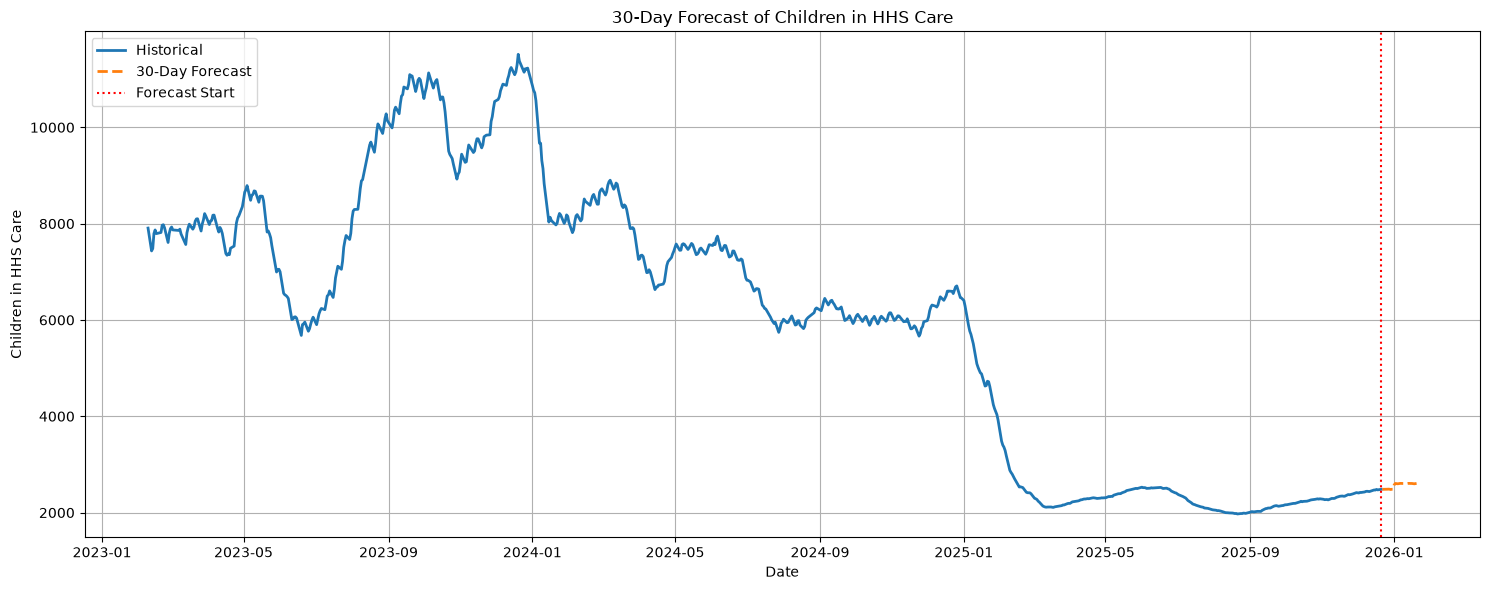

In [24]:
plt.figure(figsize=(15,6))

# Historical Data
plt.plot(
    df.index,
    df["Children in HHS Care"],
    label="Historical",
    linewidth=2
)

# Forecast
plt.plot(
    forecast_df["Date"],
    forecast_df["Predicted_HHS_Care"],
    label="30-Day Forecast",
    linestyle="--",
    linewidth=2
)

# Forecast Start
plt.axvline(
    x=df.index[-1],
    color="red",
    linestyle=":",
    label="Forecast Start"
)

plt.title("30-Day Forecast of Children in HHS Care")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
forecast_df.to_csv("../data/forecast/future_forecast.csv",index=False)
print(" Forecast saved successfully!")

 Forecast saved successfully!


Business Interpretation

The Gradient Boosting model was used to forecast the number of children expected to remain in HHS Care over the next 30 days. Under the assumption that external operational variables (such as CBP custody, transfers, and discharges) remain consistent with their latest observed values, the forecast indicates a generally stable pattern with a slight upward trend. The predicted values remain within a realistic historical range, suggesting that no sudden surge or decline is expected during the forecast period. These forecasts can support short-term resource planning, staffing, and capacity management.